# Transect Plotting with FESOMP

This notebook demonstrates how to create vertical cross-sections (transects) through 3D ocean model data using the `fesomp` library.

**Features:**
- Automatic detection of data location (nodes vs elements)
- Automatic detection of vertical coordinate (levels vs layers)
- Multiple interpolation methods (nearest neighbor, IDW, linear)
- Efficient interpolator caching for multiple variables
- Full control over plotting appearance

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import fesomp

%matplotlib inline

## 1. Load Mesh and Data

First, load the FESOM2 mesh and the ocean data we want to visualize.

In [2]:
# Load mesh
mesh = fesomp.load_mesh('/Users/nkolduno/PYTHON/DATA/CORE27_mesh/fesom.mesh.diag.nc')
print(mesh)
print(f"\nMesh has {mesh.nlev} vertical levels ({mesh.nlev-1} layers)")
print(f"Nodes: {mesh.n2d}, Elements: {mesh.nelem}")

Mesh(n2d=126858, nelem=244659, nlev=48, lon=[-180.00, 180.00], lat=[-78.52, 89.96])

Mesh has 48 vertical levels (47 layers)
Nodes: 126858, Elements: 244659


In [3]:
# Load 2D surface data (SST on nodes)
sst = xr.open_dataset('/Users/nkolduno/PYTHON/DATA/CORE27_data/sst.fesom.1958.nc')['sst'][0,:].values
print(f"SST shape: {sst.shape} (n2d nodes)")

# Load 3D temperature data (on nodes)
temp = xr.open_dataset('/Users/nkolduno/PYTHON/DATA/CORE27_data/temp.fesom.1958.nc')['temp'][0,:,:].values
print(f"Temp shape: {temp.shape} (nlev-1 layers × n2d nodes)")

# Load 3D velocity data (on triangles/elements)
u = xr.open_dataset('/Users/nkolduno/PYTHON/DATA/CORE27_data/u.fesom.1958.nc')['u'][0,:,:].values
print(f"U-velocity shape: {u.shape} (nlev-1 layers × nelem elements)")

SST shape: (126858,) (n2d nodes)
Temp shape: (47, 126858) (nlev-1 layers × n2d nodes)
U-velocity shape: (47, 244659) (nlev-1 layers × nelem elements)


## 2. Basic Transect: Atlantic Meridional Section

Create a simple transect along 30°W from 60°S to 60°N.

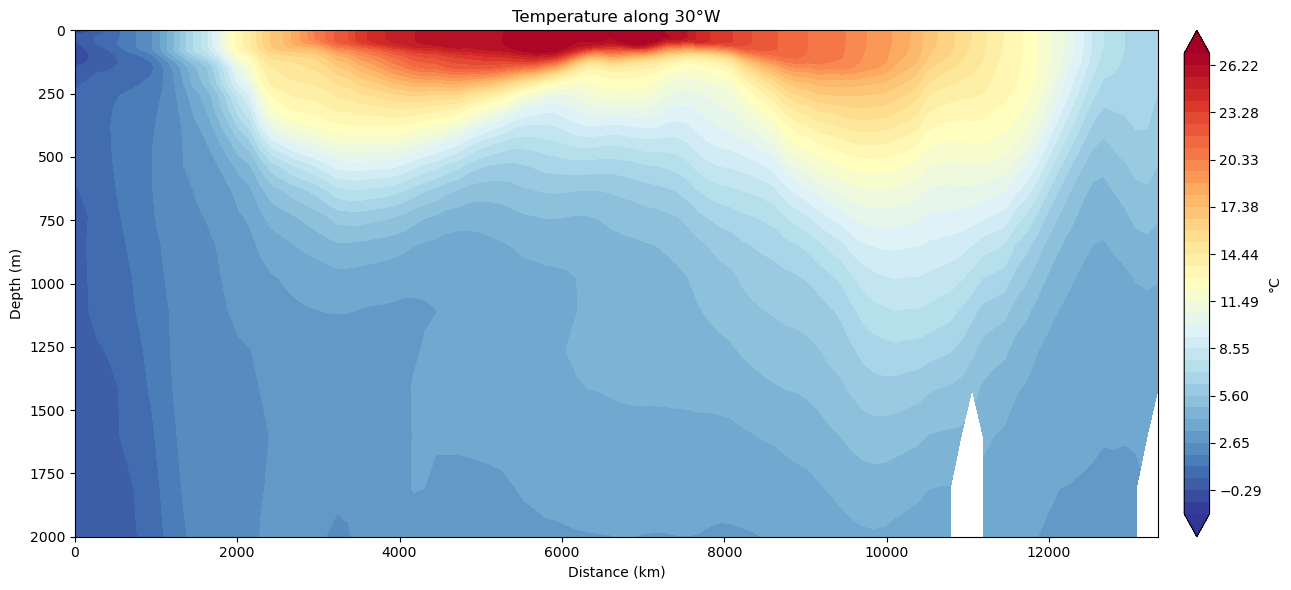

In [4]:
# Temperature transect along 30W
fig, ax, interp = fesomp.transect(
    temp,
    mesh,
    start=(-30, -60),
    end=(-30, 60),
    npoints=100,
    title="Temperature along 30°W",
    units="°C",
    cmap="RdYlBu_r",
    depth_limits=(0, 2000),  # Show top 2000m
    figsize=(14, 6),
)
plt.tight_layout()
plt.show()

## 3. Customizing the Transect Plot

You have full control over the appearance using various parameters.

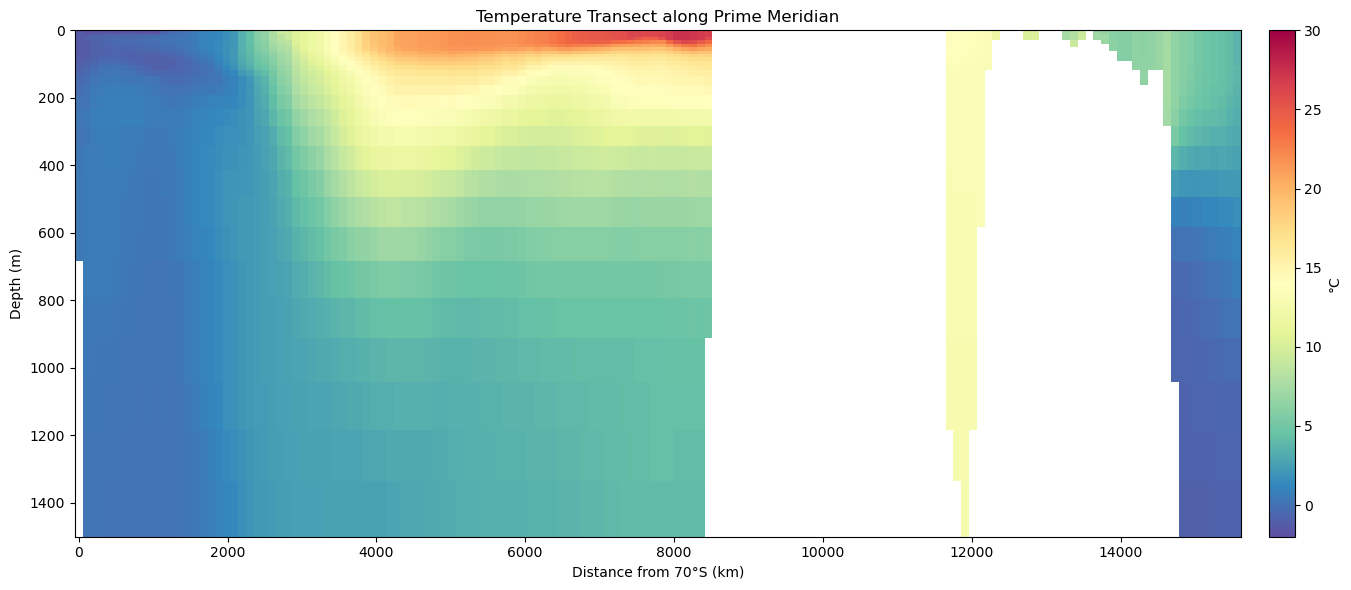

In [5]:
# Customized plot with specific contour levels
fig, ax, _ = fesomp.transect(
    temp,
    mesh,
    start=(0, -70),
    end=(0, 70),
    npoints=150,
    # Custom contour levels
    levels=(-2, 30, 30),  # (min, max, num_levels)
    # Plotting options
    ptype="pcm",  # pcolormesh instead of contourf
    cmap="Spectral_r",
    # Labels
    title="Temperature Transect along Prime Meridian",
    units="°C",
    xlabel="Distance from 70°S (km)",
    # Depth options
    depth_limits=(0, 1500),
    figsize=(15, 6),
)
plt.tight_layout()
plt.show()

## 4. Data on Elements: Velocity Transect

The library automatically detects whether data is on nodes or elements.

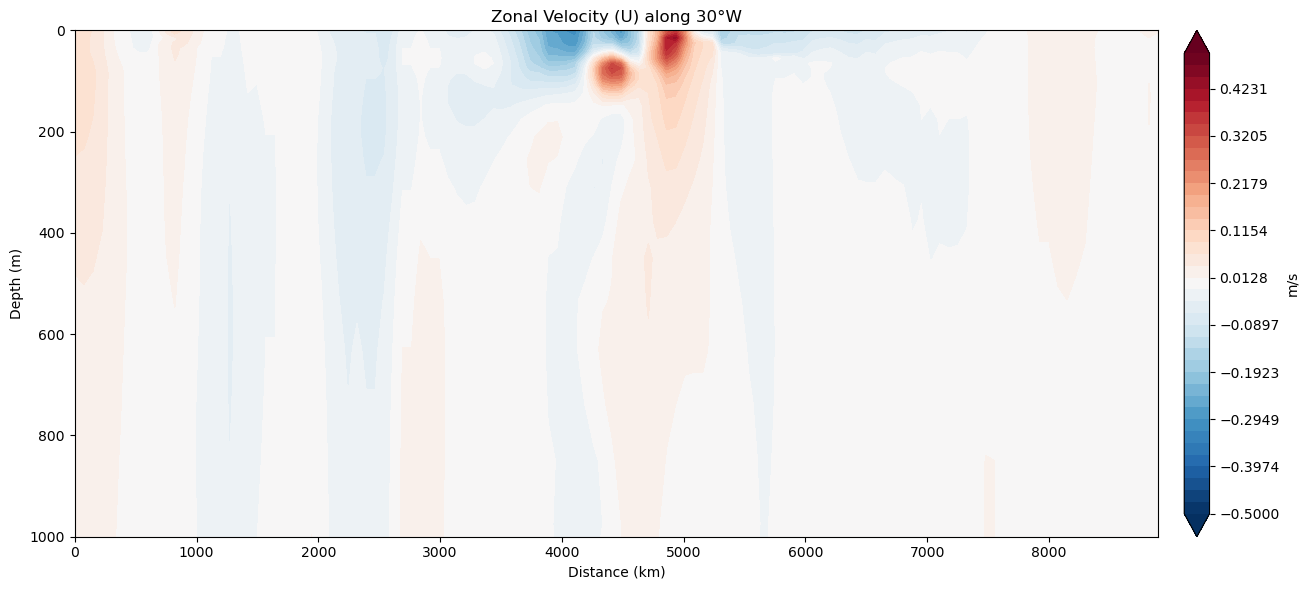

Data was on 244659 elements (automatically detected)


In [6]:
# U-velocity is defined on element centers, not nodes
# fesomp will automatically use mesh.lon_elem and mesh.lat_elem

fig, ax, _ = fesomp.transect(
    u,
    mesh,
    start=(-30, -40),
    end=(-30, 40),
    npoints=120,
    title="Zonal Velocity (U) along 30°W",
    units="m/s",
    cmap="RdBu_r",
    levels=(-0.5, 0.5, 40),
    depth_limits=(0, 1000),
    figsize=(14, 6),
)
plt.tight_layout()
plt.show()

print(f"Data was on {mesh.nelem} elements (automatically detected)")

## 5. Different Interpolation Methods

Compare the three available interpolation methods:
- **Nearest Neighbor (nn)**: Fastest, best for categorical data
- **Inverse Distance Weighting (idw)**: Smooth interpolation
- **Linear**: Most accurate but slower

In [7]:
# # Create a shorter transect to compare methods
# start, end = (10, 0), (20, 0)
# depth_range = (0, 500)

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# methods = ["nn", "idw", "linear"]
# method_names = ["Nearest Neighbor", "Inverse Distance Weighting", "Linear"]

# for ax, method, name in zip(axes, methods, method_names):
#     _, _, _ = fesomp.transect(
#         temp,
#         mesh,
#         start=start,
#         end=end,
#         npoints=80,
#         method=method,
#         ax=ax,
#         title=f"{name}",
#         units="°C",
#         cmap="RdYlBu_r",
#         depth_limits=depth_range,
#         colorbar=True,
#     )

# plt.tight_layout()
# plt.show()

## 6. Reusing Interpolators for Efficiency

When plotting multiple variables along the same transect, reuse the interpolator to save computation time.

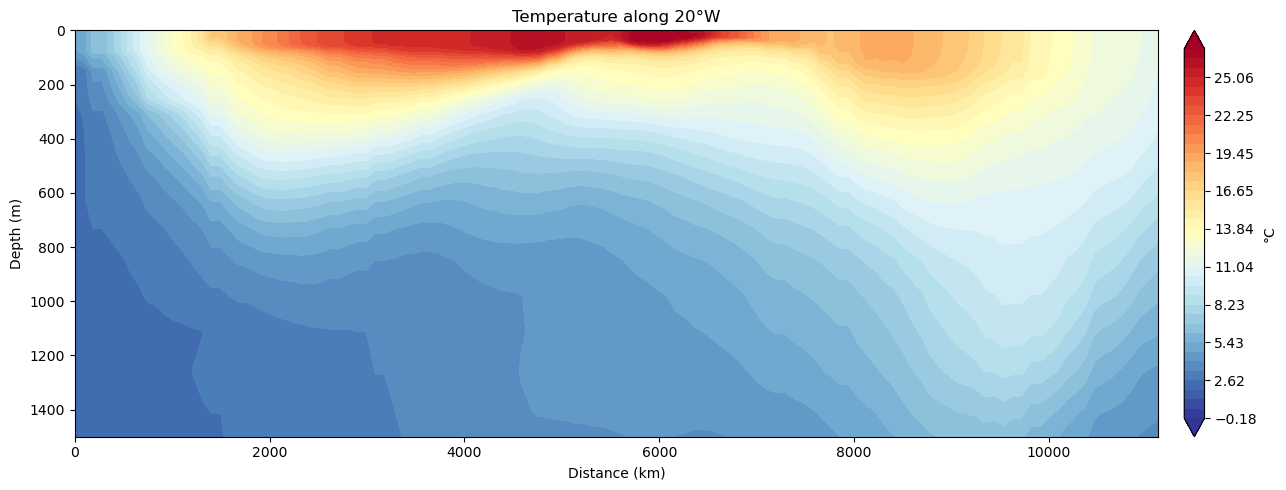

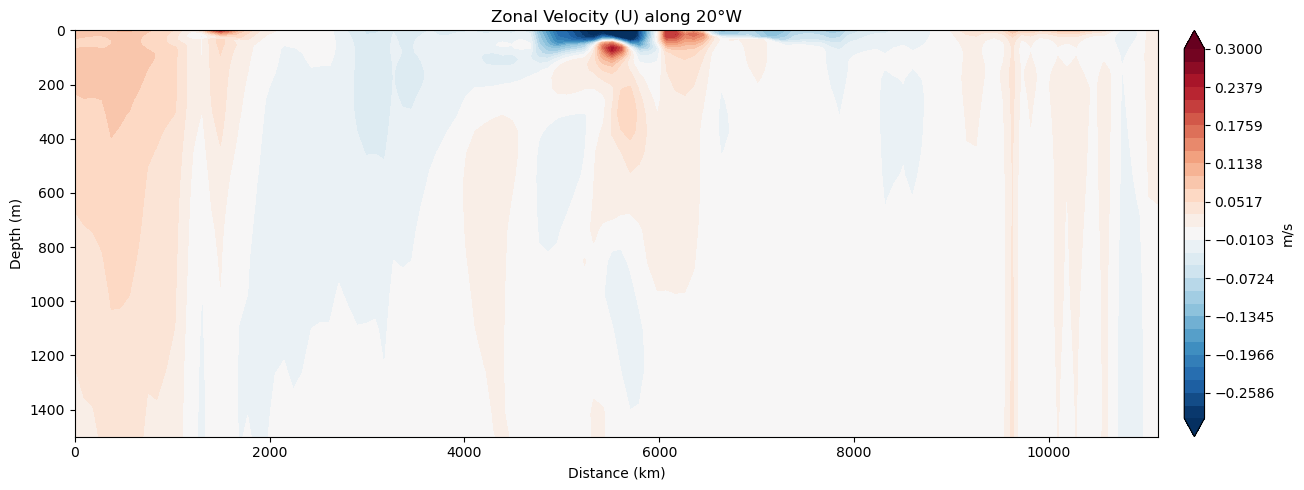

Interpolators cached for efficient repeated use!


In [8]:
# Define transect parameters
start_pt = (-20, -50)
end_pt = (-20, 50)
npts = 120
depth_max = 1500

# First variable: temperature (creates interpolator)
fig, ax, interp_temp = fesomp.transect(
    temp,
    mesh,
    start=start_pt,
    end=end_pt,
    npoints=npts,
    title="Temperature along 20°W",
    units="°C",
    cmap="RdYlBu_r",
    depth_limits=(0, depth_max),
    figsize=(14, 5),
)
plt.tight_layout()
plt.show()

# Second variable: velocity (reuses interpolator - much faster!)
# Note: We need a different interpolator for element-based data
fig, ax, interp_u = fesomp.transect(
    u,
    mesh,
    start=start_pt,
    end=end_pt,
    npoints=npts,
    # Can't reuse interp_temp because u is on elements, not nodes
    title="Zonal Velocity (U) along 20°W",
    units="m/s",
    cmap="RdBu_r",
    levels=(-0.3, 0.3, 30),
    depth_limits=(0, depth_max),
    figsize=(14, 5),
)
plt.tight_layout()
plt.show()

print("Interpolators cached for efficient repeated use!")

## 7. Separate Interpolation and Plotting

For more control, you can interpolate and plot separately.

Transect data shape: (47, 100)
Distance array shape: (100,)
Total transect length: 10008 km


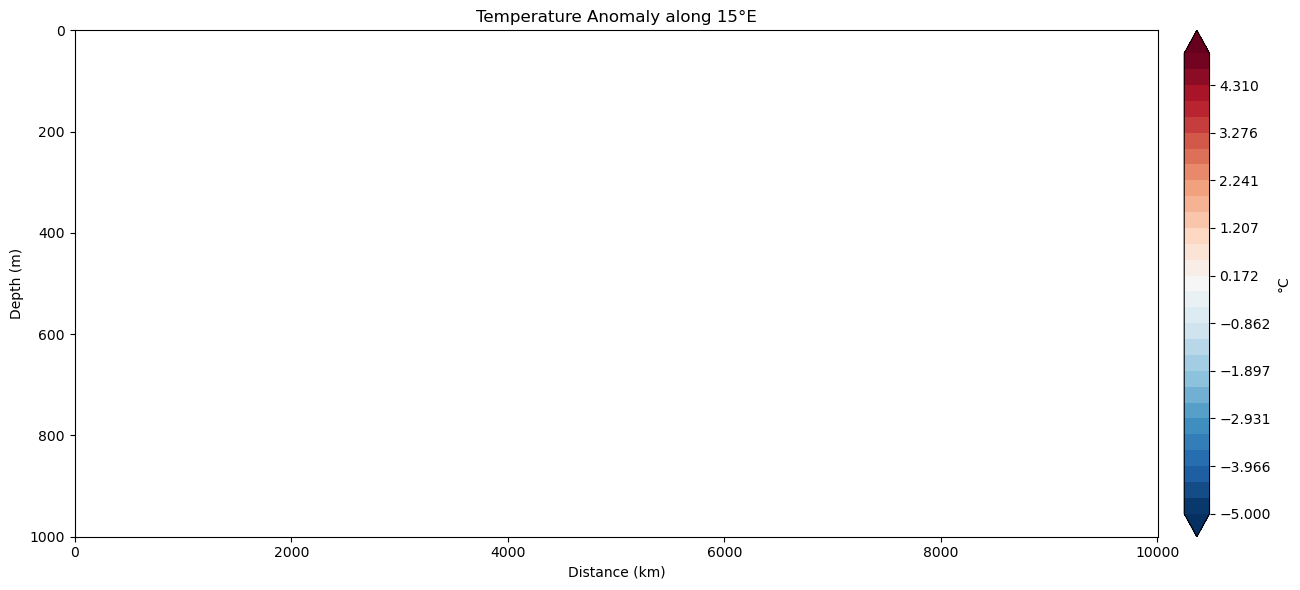

In [9]:
# Step 1: Interpolate data along transect
temp_transect, distance, interp = fesomp.interpolate_transect(
    temp,
    mesh.lon,
    mesh.lat,
    start=(15, -45),
    end=(15, 45),
    npoints=100,
    method="idw",
)

print(f"Transect data shape: {temp_transect.shape}")
print(f"Distance array shape: {distance.shape}")
print(f"Total transect length: {distance[-1]/1000:.0f} km")

# Step 2: Custom processing (e.g., compute anomaly)
mean_profile = temp_transect.mean(axis=1, keepdims=True)
temp_anomaly = temp_transect - mean_profile

# Step 3: Plot with full control
fig, ax = fesomp.plot_transect(
    temp_anomaly,
    distance,
    mesh.depth_layers,  # Explicitly specify depth coordinate
    title="Temperature Anomaly along 15°E",
    units="°C",
    cmap="RdBu_r",
    levels=(-5, 5, 30),
    depth_limits=(0, 1000),
    figsize=(14, 6),
)
plt.tight_layout()
plt.show()

## 8. Multiple Transects in One Figure

Compare different transects side by side.

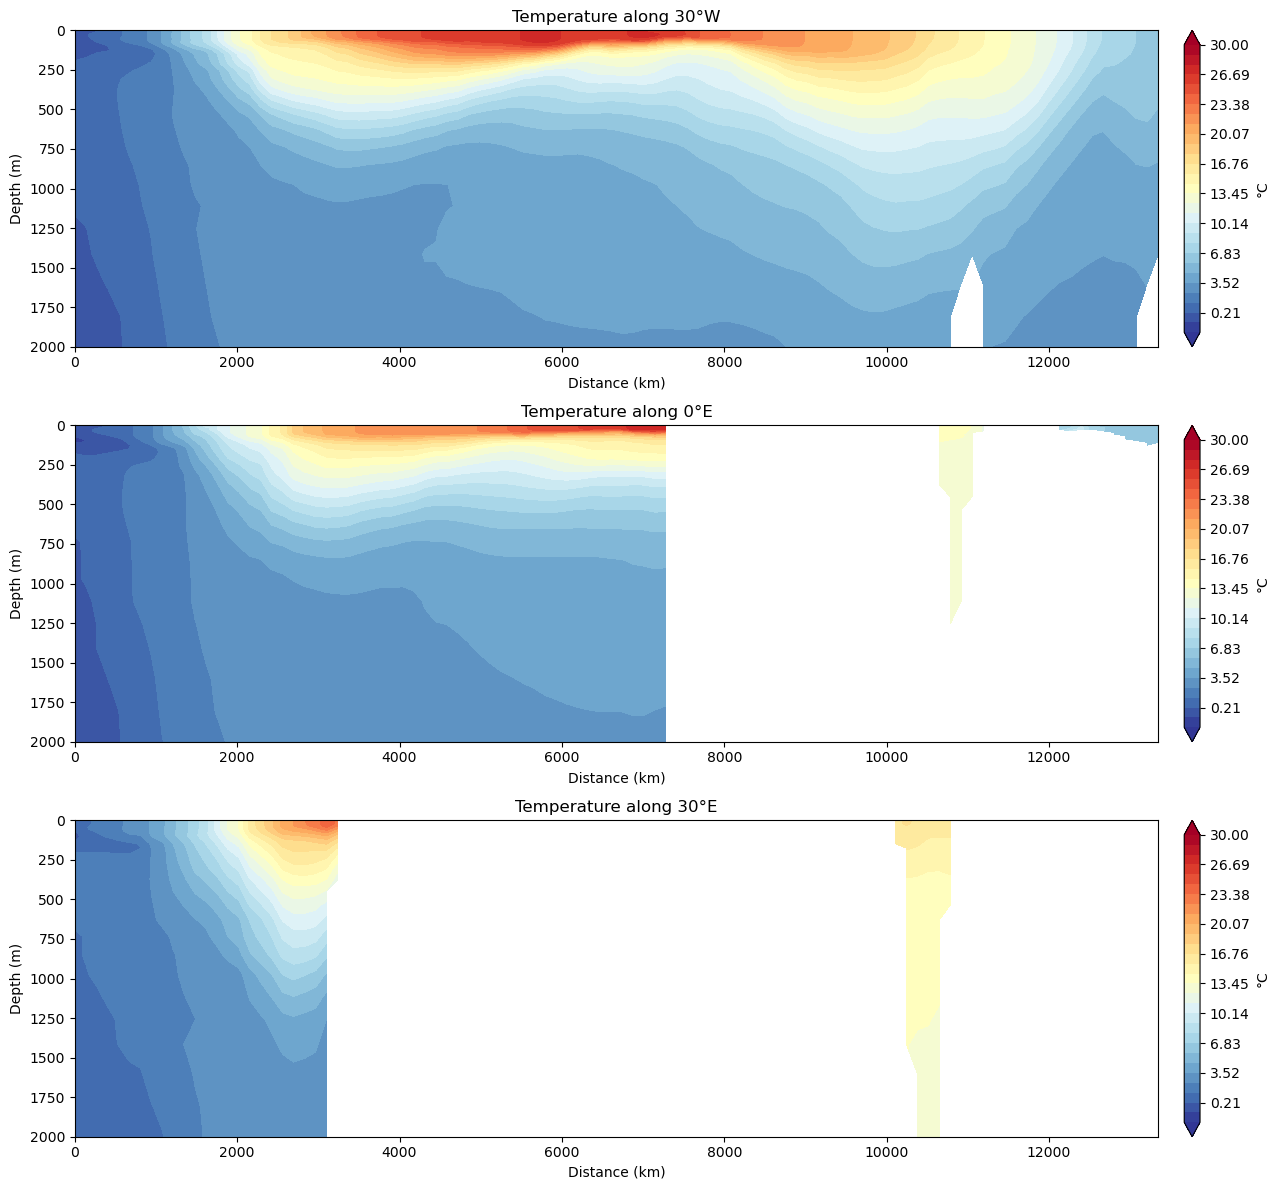

In [10]:
# Define three different transect paths
transects = [
    {"start": (-30, -60), "end": (-30, 60), "label": "30°W"},
    {"start": (0, -60), "end": (0, 60), "label": "0°E"},
    {"start": (30, -60), "end": (30, 60), "label": "30°E"},
]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, trans in zip(axes, transects):
    _, _, _ = fesomp.transect(
        temp,
        mesh,
        start=trans["start"],
        end=trans["end"],
        npoints=100,
        ax=ax,
        title=f"Temperature along {trans['label']}",
        units="°C",
        cmap="RdYlBu_r",
        depth_limits=(0, 2000),
        levels=(-2, 30, 30),
    )

plt.tight_layout()
plt.show()

## 9. Drake Passage Transect

A diagonal transect from South America to Antarctica.

In [ ]:
# Drake Passage: from Tierra del Fuego to Antarctic Peninsula
fig, ax, _ = fesomp.transect(
    temp,
    mesh,
    start=(-68, -55),  # Near Cape Horn
    end=(-62, -63),    # Near Antarctic Peninsula
    npoints=80,
    method="idw",
    title="Temperature Transect across Drake Passage",
    units="°C",
    cmap="RdYlBu_r",
    depth_limits=(0, 1500),
    figsize=(12, 6),
)
plt.tight_layout()
plt.show()

# Show path on map for reference
import cartopy.crs as ccrs

fig2, ax2, _ = fesomp.plot(
    temp[0, :],  # Surface temperature
    mesh.lon,
    mesh.lat,
    box=(-75, -55, -65, -50),
    res=(200, 150),
    titles="Drake Passage Region",
    cmap="RdYlBu_r",
    coastlines=True,
)
# Add transect line
ax2[0].plot([-68, -62], [-55, -63], 'k-', linewidth=2, transform=ccrs.PlateCarree())
ax2[0].plot([-68, -62], [-55, -63], 'wo', markersize=6, transform=ccrs.PlateCarree())
plt.show()

## 10. Summary of Key Features

**Automatic Detection:**
- Data location: nodes (n2d) vs elements (nelem)
- Vertical coordinate: levels vs layers

**Interpolation Methods:**
- `method="nn"`: Nearest neighbor (fastest)
- `method="idw"`: Inverse distance weighting (smooth, default)
- `method="linear"`: Linear interpolation (most accurate)

**Performance:**
- Reuse interpolators when plotting multiple variables on the same transect
- Pre-computed KDTree for fast spatial queries

**Customization:**
- Full control over colormaps, contour levels, labels
- Support for both contourf and pcolormesh
- Flexible depth range specification

In [ ]:
# Clean up
plt.close('all')
print("\nExamples complete!")